# Supply Chain Analytics & Inventory Optimization


### Data auditing, wrangling & feature engineering for eda:
objective: Prepare the raw supply chain dataset for downstream analysis by performing data cleaning, quality assessment, feature engineering, and dataset transformation.

**TASKS PERFORMED:**

- Data loading and inspection
- Data quality assessment
- Missing value analysis
- Duplicate checks
- Data type conversion
- Basic statistical analysis
- Feature engineering
- Export processed dataset

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df= pd.read_csv("data used/supply_chain_dataset1.csv")
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


#### NOTE:
This project focuses on analyzing historical sales, inventory, procurement, and warehouse operations to build a demand forecasting and inventory optimization system.

The following column is intentionally excluded from the initial analysis and will be revisited in later stages of the project:

- **demand_forecast**: ignored during EDA and forecasting to avoid data leakage. A custom forecasting model will be developed and its predictions will later be compared against this column.



In [4]:
print(df.shape)
print(df.info())


(91250, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_For

In [5]:
df.isnull().sum().to_frame()

,0
Date,0
SKU_ID,0
Warehouse_ID,0
Supplier_ID,0
Region,0
Units_Sold,0
Inventory_Level,0
Supplier_Lead_Time_Days,0
Reorder_Point,0
Order_Quantity,0


In [6]:
df.nunique().to_frame()

,0
Date,365
SKU_ID,50
Warehouse_ID,5
Supplier_ID,10
Region,4
Units_Sold,58
Inventory_Level,781
Supplier_Lead_Time_Days,13
Reorder_Point,142
Order_Quantity,301


In [7]:
df.describe()

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
std,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000


- for units sold, mean and median are almost identical and a std dev of 9.06 suggests bell curve for data.
- quantity suggests skewness since std dev is very large as compared to mean. 
- mean for promtional flags is 0.10 so it happens rarely (10% events)
- stockouts are basically 0

In [8]:
df.describe(include='object')

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region
count,91250,91250,91250,91250,91250
unique,365,50,5,10,4
top,2024-01-01,SKU_1,WH_1,SUP_7,North
freq,250,1825,18250,12410,22974


- 50 Stock keeping units 
- 5 warehouses
- 10 suppliers 
- 4 regions (North, West, South, East)
- 365 days

In [9]:
#converting date to datetime:
df['Date']= pd.to_datetime(df['Date'])
print(df['Date'].dtype)
print(df['Date'].min())
print(df['Date'].max())

datetime64[ns]
2024-01-01 00:00:00
2024-12-30 00:00:00


time period: january 1, 2024 to december 30, 2024

In [10]:
#duplicated rows:
df.duplicated().sum()

np.int64(0)

<Axes: >

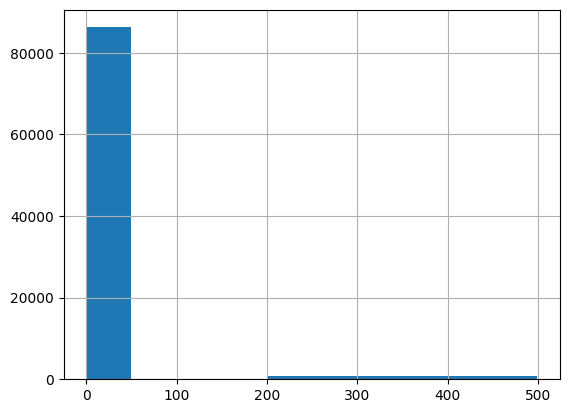

In [11]:
df['Order_Quantity'].hist() #data is right skewed

In [12]:
#calculating coeff of variance for forecasting: 
numeric_cols=['Units_Sold' , 'Inventory_Level','Supplier_Lead_Time_Days','Reorder_Point','Order_Quantity','Unit_Cost','Unit_Price','Promotion_Flag','Stockout_Flag']
for col in numeric_cols:
    print(col,':', round((df[col].std()/df[col].mean())*100,2))

Units_Sold : 45.22
Inventory_Level : 28.31
Supplier_Lead_Time_Days : 48.95
Reorder_Point : 18.29
Order_Quantity : 427.25
Unit_Cost : 37.49
Unit_Price : 38.99
Promotion_Flag : 297.38
Stockout_Flag : nan


C:\Users\Pavni Rastogi\AppData\Local\Temp\ipykernel_49416\4268910168.py:4: RuntimeWarning: invalid value encountered in scalar divide
  print(col,':', round((df[col].std()/df[col].mean())*100,2))


- from coeff of variance we can clearly observe that the cv for units sold is 45% i.e. its stable day to day and shows some variation but huge cv for order quantity.
- so orders are placed infrequently probably but when placed, they're in large scale. 
- maybe, ordering stocks isn't in sync with sales which might be leading to too much stock on some days (increased storage cost) and too little on other (stockouts)
- so we can investigate this further & use forecasting to solve this problem. 
- can check if the current inventory policy and stocking system is optimal.
- other metrics such as supplier lead time, unit cost & price etc are stable as well. 

#

### Feature Engineering

1. Financial Features:

In [13]:
#revenue (for each row: for easier aggregation in finding daily, weekly, monthly revenue)
df['revenue']= df['Units_Sold']*df['Unit_Price']

#buying cost of products sold:
df['buying_cost']= df['Units_Sold']*df['Unit_Cost']

#profit per unit
df['unit_profit']= df['Unit_Price']-df['Unit_Cost']

#total profit:
df['profit']= df['revenue']-df['buying_cost']

#profit margin %
df['profit_margin']= np.where(df['revenue']==0,0, (df['profit']/df['revenue'])*100)

#inventory value
df['inventory_value']= df['Inventory_Level']*df['Unit_Cost']


In [14]:
#renaming buying cost to standard 'cost of goods sold' 
df= df.rename(columns={'buying_cost':'cogs'})

2. Time series based features

In [15]:
df['year']= df['Date'].dt.year
df['month']= df['Date'].dt.month
df['month_name']= df['Date'].dt.month_name()
df['Quarter']= df['Date'].dt.quarter
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_name'] = df['Date'].dt.day_name()

3. Inventory features

In [16]:
#reordering needed flag:  (0-no, 1-yes)
df['reorder_needed']= (df['Inventory_Level']<=df['Reorder_Point']).astype(int)

#how far is inventory from reorder point; if negative- below reorder point else buffer available
df['inventory_difference']= df['Inventory_Level']-df['Reorder_Point']

In [17]:
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast,revenue,cogs,unit_profit,profit,profit_margin,inventory_value,year,month,month_name,Quarter,day,day_of_week,day_name,reorder_needed,inventory_difference
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52,204.80,139.50,6.53,65.30,31.884766,8258.40,2024,1,January,1,1,0,Monday,0,213
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63,348.16,237.15,6.53,111.01,31.884766,8021.25,2024,1,January,1,2,1,Tuesday,0,196
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62,716.80,488.25,6.53,228.55,31.884766,7533.00,2024,1,January,1,3,2,Wednesday,0,161
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43,491.52,334.80,6.53,156.72,31.884766,7198.20,2024,1,January,1,4,3,Thursday,0,137
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70,430.08,292.95,6.53,137.13,31.884766,6905.25,2024,1,January,1,5,4,Friday,0,116


In [18]:
#standardising column names in lowercase:
df.columns= df.columns.str.lower()
print(df.columns)

Index(['date', 'sku_id', 'warehouse_id', 'supplier_id', 'region', 'units_sold',
       'inventory_level', 'supplier_lead_time_days', 'reorder_point',
       'order_quantity', 'unit_cost', 'unit_price', 'promotion_flag',
       'stockout_flag', 'demand_forecast', 'revenue', 'cogs', 'unit_profit',
       'profit', 'profit_margin', 'inventory_value', 'year', 'month',
       'month_name', 'quarter', 'day', 'day_of_week', 'day_name',
       'reorder_needed', 'inventory_difference'],
      dtype='object')


In [19]:
df.to_csv(r"C:\Users\Pavni Rastogi\Desktop\supply-chain-analytics-project\data used\processed_supply_chain.csv", index=False)

*NOTE:*

- **inventory_status**: will be engineered after forecasting and inventory optimization based on optimized inventory policies rather than predefined rules.

In [20]:
df.drop(columns=['month_name', 'day_name', 'demand_forecast']).to_csv("raw_supply_chain.csv", index=False)
